### **Installing Libraries**

In [ ]:
!pip -q install geopandas rdflib shapely pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 5.8 MB/s eta 0:00:00


### **Importing Libraries**

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from rdflib.namespace import XSD
from shapely.geometry import LineString, Polygon
from rdflib import Graph, Namespace, Literal, RDF, URIRef
from rdflib.plugins.sparql import prepareQuery

### **Creating Two Unlinked Geospatial Datasets**

In [ ]:
# ROAD DATASET
roads_data = {
    "road_id": ["R1", "R2", "R3"],
    "road_name": ["Main Road", "Forest Road", "Village Road"],
    "road_type": ["Highway", "Local", "Local"],
    "geometry": [
        LineString([(0, 0), (10, 10)]),
        LineString([(2, 8), (8, 2)]),
        LineString([(0, 5), (10, 5)])
    ]
}

roads = gpd.GeoDataFrame(roads_data, geometry="geometry", crs="EPSG:4326")

In [ ]:
print("Road Dataset:")
print(roads)

Road Dataset:
  road_id     road_name road_type                 geometry
0      R1     Main Road   Highway  LINESTRING (0 0, 10 10)
1      R2   Forest Road     Local    LINESTRING (2 8, 8 2)
2      R3  Village Road     Local   LINESTRING (0 5, 10 5)


In [ ]:
# LAND COVER DATASET
land_data = {
    "land_id": ["L1", "L2", "L3"],
    "land_type": ["Forest", "Agricultural", "Residential"],
    "area": [25.0, 30.0, 20.0],
    "geometry": [
        Polygon([(1, 1), (5, 1), (5, 5), (1, 5)]),
        Polygon([(5, 5), (9, 5), (9, 9), (5, 9)]),
        Polygon([(2, 6), (8, 6), (8, 9), (2, 9)])
    ]
}

land = gpd.GeoDataFrame(land_data, geometry="geometry", crs="EPSG:4326")

In [ ]:
print("Land Cover Dataset:")
print(land)

Land Cover Dataset:
  land_id     land_type  area                             geometry
0      L1        Forest  25.0  POLYGON ((1 1, 5 1, 5 5, 1 5, 1 1))
1      L2  Agricultural  30.0  POLYGON ((5 5, 9 5, 9 9, 5 9, 5 5))
2      L3   Residential  20.0  POLYGON ((2 6, 8 6, 8 9, 2 9, 2 6))


### **Analyzing Schemas**

In [ ]:
print("ROAD DATASET SCHEMA")
print(roads.dtypes)

ROAD DATASET SCHEMA
road_id        object
road_name      object
road_type      object
geometry     geometry
dtype: object


In [ ]:
print("Spatial Field:", roads.geometry.name)

Spatial Field: geometry


In [ ]:
print("Geometry Type:")
print(roads.geometry.geom_type.value_counts())

Geometry Type:
LineString    3
Name: count, dtype: int64


In [ ]:
print("Attribute Fields:", [col for col in roads.columns if col != "geometry"])

Attribute Fields: ['road_id', 'road_name', 'road_type']


In [ ]:
print("LAND COVER DATASET SCHEMA")
print(land.dtypes)

LAND COVER DATASET SCHEMA
land_id        object
land_type      object
area          float64
geometry     geometry
dtype: object


In [ ]:
print("Spatial Field:", land.geometry.name)

Spatial Field: geometry


In [ ]:
print("Geometry Type:", land.geometry.geom_type.value_counts())

Geometry Type: Polygon    3
Name: count, dtype: int64


In [ ]:
print("Attribute Fields:", [col for col in land.columns if col != "geometry"])

Attribute Fields: ['land_id', 'land_type', 'area']


### **Visualizing both Datasets**

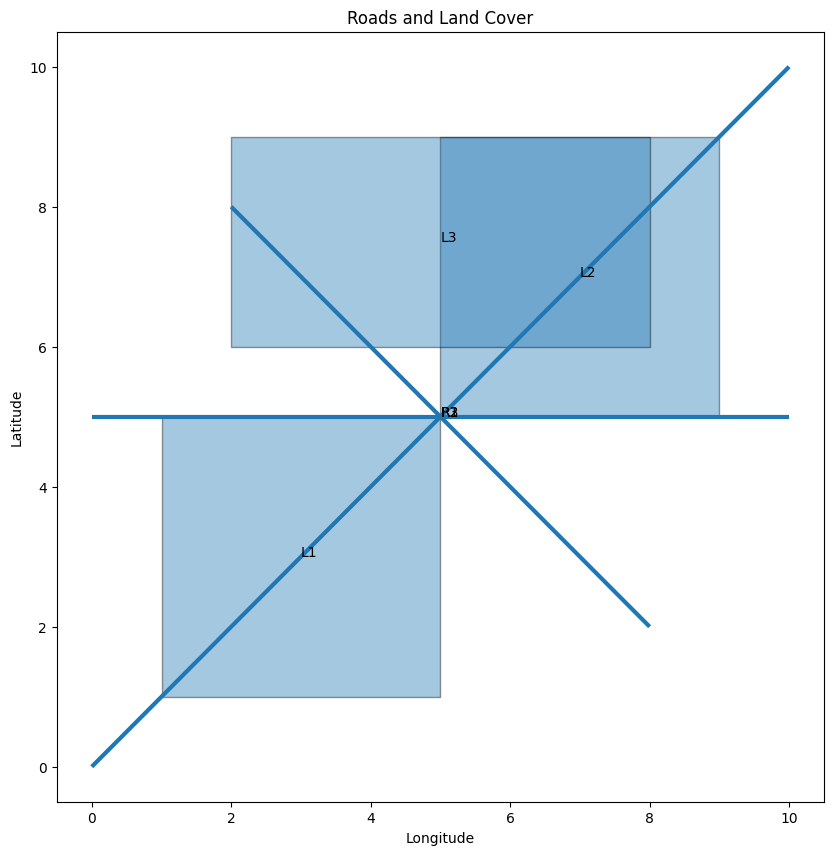

In [ ]:
ax = land.plot(figsize=(10, 10), alpha=0.4, edgecolor="black")

roads.plot(ax=ax, linewidth=3)

for idx, row in roads.iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(x, y, row.road_id)

for idx, row in land.iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(x, y, row.land_id)

plt.title("Roads and Land Cover")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### **Creating RDF / GeoSPARQL Graph**

In [ ]:
# Create RDF graph
g = Graph()

# Namespaces
EX = Namespace("http://example.org/ontology/")
GEO = Namespace("http://www.opengis.net/ont/geosparql#")
GEOF = Namespace("http://www.opengis.net/def/function/geosparql/")

g.bind("ex", EX)
g.bind("geo", GEO)

# GeoSPARQL geometry datatype
GEO_WKT = URIRef("http://www.opengis.net/ont/geosparql#wktLiteral")

In [ ]:
# ADD ROADS TO RDF

for _, row in roads.iterrows():

    road_uri = EX[row["road_id"]]
    geom_uri = EX[row["road_id"] + "_Geometry"]

    # Road class
    g.add((road_uri, RDF.type, EX.RoadSegment))

    # Attributes
    g.add((road_uri, EX.roadName, Literal(row["road_name"])))

    g.add((road_uri, EX.roadType, Literal(row["road_type"])))

    # Geometry relation
    g.add((road_uri, GEO.hasGeometry, geom_uri))

    # Geometry type
    g.add((geom_uri, RDF.type, GEO.Geometry))

    # WKT geometry
    g.add((geom_uri, GEO.asWKT, Literal(row.geometry.wkt, datatype=GEO_WKT)))

In [ ]:
# ADD LAND COVER TO RDF

for _, row in land.iterrows():

    land_uri = EX[row["land_id"]]
    geom_uri = EX[row["land_id"] + "_Geometry"]

    # Land Cover class
    g.add((land_uri, RDF.type, EX.LandCover))

    # Attributes
    g.add((land_uri, EX.landType, Literal(row["land_type"])))

    g.add((land_uri, EX.area, Literal(row["area"], datatype=XSD.double)))

    # Geometry relation
    g.add((land_uri, GEO.hasGeometry, geom_uri))

    # Geometry type
    g.add((geom_uri, RDF.type, GEO.Geometry))

    # WKT geometry
    g.add((geom_uri, GEO.asWKT, Literal(row.geometry.wkt, datatype=GEO_WKT)))

In [ ]:
print("RDF graph created successfully!")
print("Total RDF triples:", len(g))

RDF graph created successfully!
Total RDF triples: 36


### **Displaying RDF Triples**

In [ ]:
print(g.serialize(format="turtle"))

@prefix ex: <http://example.org/ontology/> .
@prefix geo: <http://www.opengis.net/ont/geosparql#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

ex:L1 a ex:LandCover ;
    ex:area 2.5e+01 ;
    ex:landType "Forest" ;
    geo:hasGeometry ex:L1_Geometry .

ex:L2 a ex:LandCover ;
    ex:area 3e+01 ;
    ex:landType "Agricultural" ;
    geo:hasGeometry ex:L2_Geometry .

ex:L3 a ex:LandCover ;
    ex:area 2e+01 ;
    ex:landType "Residential" ;
    geo:hasGeometry ex:L3_Geometry .

ex:R1 a ex:RoadSegment ;
    ex:roadName "Main Road" ;
    ex:roadType "Highway" ;
    geo:hasGeometry ex:R1_Geometry .

ex:R2 a ex:RoadSegment ;
    ex:roadName "Forest Road" ;
    ex:roadType "Local" ;
    geo:hasGeometry ex:R2_Geometry .

ex:R3 a ex:RoadSegment ;
    ex:roadName "Village Road" ;
    ex:roadType "Local" ;
    geo:hasGeometry ex:R3_Geometry .

ex:L1_Geometry a geo:Geometry ;
    geo:asWKT "POLYGON ((1 1, 5 1, 5 5, 1 5, 1 1))"^^geo:wktLiteral .

ex:L2_Geometry a geo:Geometry ;
    geo:asWK

### **Saving RDF File**

In [ ]:
g.serialize(destination="linked_geospatial_data.ttl", format="turtle")

print("RDF file saved as linked_geospatial_data.ttl")

RDF file saved as linked_geospatial_data.ttl


In [ ]:
from google.colab import files

files.download("linked_geospatial_data.ttl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Performing Spatial Interlinking**

In [ ]:
# Spatial links
spatial_links = []

for road_idx, road_row in roads.iterrows():

    for land_idx, land_row in land.iterrows():

        if road_row.geometry.intersects(land_row.geometry):

            road_id = road_row["road_id"]
            land_id = land_row["land_id"]

            spatial_links.append((road_id, land_id))

            # Add spatial relationship to RDF
            g.add((EX[road_id], GEO.sfIntersects, EX[land_id]))

print("Spatial links found:")
for road_id, land_id in spatial_links:
    print(road_id, "→ geo:sfIntersects →", land_id)

Spatial links found:
R1 → geo:sfIntersects → L1
R1 → geo:sfIntersects → L2
R1 → geo:sfIntersects → L3
R2 → geo:sfIntersects → L1
R2 → geo:sfIntersects → L2
R2 → geo:sfIntersects → L3
R3 → geo:sfIntersects → L1
R3 → geo:sfIntersects → L2


### **Displaying Linked Datasets**

In [ ]:
print("PATIAL LINKS\n")

for road_id, land_id in spatial_links:

    print(
        f"{road_id} "
        f"---- geo:sfIntersects ----> "
        f"{land_id}"
    )

PATIAL LINKS

R1 ---- geo:sfIntersects ----> L1
R1 ---- geo:sfIntersects ----> L2
R1 ---- geo:sfIntersects ----> L3
R2 ---- geo:sfIntersects ----> L1
R2 ---- geo:sfIntersects ----> L2
R2 ---- geo:sfIntersects ----> L3
R3 ---- geo:sfIntersects ----> L1
R3 ---- geo:sfIntersects ----> L2


### **SPARQL Query**

In [ ]:
query = """
PREFIX ex: <http://example.org/ontology/>
PREFIX geo: <http://www.opengis.net/ont/geosparql#>

SELECT ?road ?land
WHERE {
    ?road a ex:RoadSegment ;
          geo:sfIntersects ?land .

    ?land a ex:LandCover .
}
"""

results = g.query(query)

print("Roads intersecting Land Cover:\n")

for row in results:
    print(row.road, "→", row.land)

Roads intersecting Land Cover:

http://example.org/ontology/R1 → http://example.org/ontology/L1
http://example.org/ontology/R2 → http://example.org/ontology/L1
http://example.org/ontology/R3 → http://example.org/ontology/L1
http://example.org/ontology/R1 → http://example.org/ontology/L2
http://example.org/ontology/R2 → http://example.org/ontology/L2
http://example.org/ontology/R3 → http://example.org/ontology/L2
http://example.org/ontology/R1 → http://example.org/ontology/L3
http://example.org/ontology/R2 → http://example.org/ontology/L3


### **Better SPARQL Query with names**

In [ ]:
query = """
PREFIX ex: <http://example.org/ontology/>
PREFIX geo: <http://www.opengis.net/ont/geosparql#>

SELECT ?road ?roadName ?land ?landType
WHERE {

    ?road a ex:RoadSegment ;
          ex:roadName ?roadName ;
          geo:sfIntersects ?land .

    ?land a ex:LandCover ;
          ex:landType ?landType .
}
"""

results = g.query(query)

print("LINKED DATA RESULTS\n")

for row in results:

    print(
        f"Road: {row.roadName}\n"
        f"Land Cover: {row.landType}\n"
        f"Relationship: geo:sfIntersects\n"
    )

LINKED DATA RESULTS

Road: Main Road
Land Cover: Forest
Relationship: geo:sfIntersects

Road: Forest Road
Land Cover: Forest
Relationship: geo:sfIntersects

Road: Village Road
Land Cover: Forest
Relationship: geo:sfIntersects

Road: Main Road
Land Cover: Agricultural
Relationship: geo:sfIntersects

Road: Forest Road
Land Cover: Agricultural
Relationship: geo:sfIntersects

Road: Village Road
Land Cover: Agricultural
Relationship: geo:sfIntersects

Road: Main Road
Land Cover: Residential
Relationship: geo:sfIntersects

Road: Forest Road
Land Cover: Residential
Relationship: geo:sfIntersects



### **Validating Spatial Links**

In [ ]:
print("VALIDATION\n")

validation_count = 0

for road_idx, road_row in roads.iterrows():
    for land_idx, land_row in land.iterrows():
        actual_intersection = road_row.geometry.intersects(land_row.geometry)
        rdf_link = ((EX[road_row["road_id"]], GEO.sfIntersects, EX[land_row["land_id"]]) in g)

        if actual_intersection == rdf_link:
            validation_count += 1
            print(
                f"{road_row['road_id']} - "
                f"{land_row['land_id']} : VALID"
            )
        else:
            print(
                f"{road_row['road_id']} - "
                f"{land_row['land_id']} : INVALID"
            )
print(
    f"\nValidation completed: "
    f"{validation_count} geometry relationships checked."
)

VALIDATION

R1 - L1 : VALID
R1 - L2 : VALID
R1 - L3 : VALID
R2 - L1 : VALID
R2 - L2 : VALID
R2 - L3 : VALID
R3 - L1 : VALID
R3 - L2 : VALID
R3 - L3 : VALID

Validation completed: 9 geometry relationships checked.


### **Counting RDF Triples**

In [ ]:
print("RDF GRAPH VALIDATION")

print("Total RDF triples:", len(g))

print("Road entities:", len(list(g.subjects(RDF.type, EX.RoadSegment))))

print("Land Cover entities:", len(list(g.subjects(RDF.type, EX.LandCover))))

print("Spatial links:", len(list(g.triples((None, GEO.sfIntersects, None)))))

RDF GRAPH VALIDATION
Total RDF triples: 44
Road entities: 3
Land Cover entities: 3
Spatial links: 8


### **Saving Final Linked RDF**

In [ ]:
g.serialize(destination="final_linked_geospatial_data.ttl", format="turtle")

print("Final linked RDF dataset created successfully.")

Final linked RDF dataset created successfully.


In [ ]:
files.download("final_linked_geospatial_data.ttl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Interpretation**

The experiment successfully demonstrates the transformation of two unlinked geospatial datasets, Roads and Land Cover, into linked geospatial data using RDF and GeoSPARQL. The schemas of both datasets were analyzed to identify their spatial and attribute fields. The datasets were represented as RDF triples, with their geometries encoded using `geo:asWKT`. GeoSPARQL concepts were used to define spatial entities and their geometries. Spatial relationships between roads and land-cover regions were identified using `geo:sfIntersects`. SPARQL queries were then used to retrieve the linked road and land-cover features. The validation step confirmed that the generated spatial links corresponded with the actual geometric intersections between the datasets.

## **Conclusion**

Thus, two independent geospatial datasets were successfully converted into RDF and interlinked using GeoSPARQL spatial relationships. The experiment demonstrated how RDF, geospatial ontologies, WKT geometry representation, and SPARQL can be used to integrate heterogeneous geospatial data. The use of `geo:sfIntersects` enabled spatial relationships between roads and land-cover areas to be represented and queried as linked data. This approach provides a semantic framework for integrating, querying, and validating geospatial datasets.

## **Colab File:** https://colab.research.google.com/drive/18jIDI0Ioj88kYhGZU28XJMHIe4BFLoFm?usp=sharing